In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy import stats

# paths
BASE      = "/Users/jr11/bachelor_thesis"
LOGS_DIR  = os.path.join(BASE, "decision_logs")
QUALTRICS = os.path.join(BASE, "qualtrics_data", "Bachelor Questionnaire_May 10, 2026_13.08.csv")
    
# filename correction map - participants who entered wrong ID in the game
filename_corrections = {
    "decision_log_40_1774615281.csv": 4,
    "decision_log_40_1774874608.csv": 40,
    "decision_log_50_1774615486.csv": 5,
    "decision_log_50_1774881701.csv": 50,
    "decision_log_39_1774618554.csv": 9,
    "decision_log_39_1774874283.csv": 39,
    "decision_log_184_1774622235.csv": 18,
    "decision_log_190_1774622537.csv": 14,
    "decision_log_224_1774625616.csv": 22,
    "decision_log_234_1774626183.csv": 23,
    "decision_log_5_1774953912.csv": 56,
}

# qualtrics correction map - participants who entered wrong ID in the survey
qualtrics_corrections = {
    "40": 4, "50": 5, "39": 9,
    "184": 18, "190": 14, "224": 22, "234": 23, "5b": 56,
}

print("ready")

ready


In [4]:
# load all game logs and apply filename corrections
all_logs = []

for filename in os.listdir(LOGS_DIR):
    if not filename.endswith(".csv"):
        continue
    
    filepath = os.path.join(LOGS_DIR, filename)
    df = pd.read_csv(filepath)
    
    # use filename correction map if applicable
    if filename in filename_corrections:
        df["participant_id"] = filename_corrections[filename]
    else:
        # extract ID from filename: decision_log_XX_timestamp.csv
        try:
            pid = int(filename.split("_")[2])
            df["participant_id"] = pid
        except:
            print(f"could not parse: {filename}")
            continue
    
    all_logs.append(df)

game_log = pd.concat(all_logs, ignore_index=True)
# remove GAME_FINISH rows - these are not decisions and should not be analysed
game_log = game_log[game_log["decision_id"] != "GAME_FINISH"]


print(f"total rows: {len(game_log)}")
print(f"participants: {game_log['participant_id'].nunique()}")
print(f"IDs: {sorted(game_log['participant_id'].unique())}")


total rows: 6492
participants: 87
IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(67), np.int64(68), np.int64(69), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(81), np.int64(82), np.int64(83), np.int64(84), np.

In [5]:
# load qualtrics, skip the two header rows qualtrics exports by default
qualtrics = pd.read_csv(QUALTRICS, skiprows=[1, 2])
qualtrics = qualtrics.rename(columns={
    "age#1_1_1": "age",
    "Q126": "participant_id_raw"
})

# clean participant ID
qualtrics["participant_id_raw"] = qualtrics["participant_id_raw"].astype(str).str.strip()

# apply corrections
def correct_qualtrics_id(raw):
    if raw in qualtrics_corrections:
        return qualtrics_corrections[raw]
    try:
        return int(float(raw))
    except:
        return None

qualtrics["participant_id"] = qualtrics["participant_id_raw"].apply(correct_qualtrics_id)

# exclude participants who did not finish the game - Q132 == 2 means not finished
before = len(qualtrics)
qualtrics = qualtrics[qualtrics["Q132"] == 1]
after = len(qualtrics)

print(f"excluded {before - after} who did not finish")
print(f"remaining: {after}")
print(f"IDs: {sorted(qualtrics['participant_id'].dropna().astype(int).tolist())}")

excluded 2 who did not finish
remaining: 86
IDs: [1, 2, 3, 4, 4, 5, 5, 6, 7, 8, 9, 9, 10, 11, 12, 14, 15, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 35, 36, 37, 38, 41, 43, 44, 45, 46, 47, 48, 49, 51, 52, 55, 56, 57, 58, 59, 60, 61, 62, 63, 67, 68, 69, 73, 74, 75, 76, 77, 79, 81, 82, 83, 84, 85, 87, 88, 89, 90, 91, 98, 99, 100, 101, 102, 103, 104, 105, 106, 111, 117, 123]


In [6]:
# fix duplicate IDs - earlier date = mistyped participant, later date = real participant, noted down during experiment
qualtrics.loc[36, "participant_id"] = 40
qualtrics.loc[45, "participant_id"] = 50
qualtrics.loc[35, "participant_id"] = 39

# verify
dupes = qualtrics["participant_id"].value_counts()
dupes = dupes[dupes > 1]
print(f"remaining duplicates: {len(dupes)}")
print(f"unique participants: {qualtrics['participant_id'].nunique()}")
print(f"IDs: {sorted(qualtrics['participant_id'].dropna().astype(int).tolist())}")


remaining duplicates: 0
unique participants: 86
IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 35, 36, 37, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 55, 56, 57, 58, 59, 60, 61, 62, 63, 67, 68, 69, 73, 74, 75, 76, 77, 79, 81, 82, 83, 84, 85, 87, 88, 89, 90, 91, 98, 99, 100, 101, 102, 103, 104, 105, 106, 111, 117, 123]


In [7]:
# assign condition - odd = embody, even = observer
game_log["condition"] = game_log["participant_id"].apply(
    lambda x: "Embody" if x % 2 != 0 else "Observer"
)

# check who is missing on either side
q_ids = set(qualtrics["participant_id"].dropna().astype(int))
g_ids = set(game_log["participant_id"].unique())
print(f"in qualtrics but not game log: {sorted(q_ids - g_ids)}")
print(f"in game log but not qualtrics: {sorted(g_ids - q_ids)}")

# exclude unmatched participants
qualtrics = qualtrics[qualtrics["participant_id"] != 79]
game_log = game_log[~game_log["participant_id"].isin([16, 32])]

# final merge
merged = pd.merge(
    qualtrics,
    game_log[["participant_id", "condition"]].drop_duplicates(),
    on="participant_id",
    how="inner"
)

print(f"\nfinal N: {len(merged)}")
print(f"Embody: {(merged['condition'] == 'Embody').sum()}")
print(f"Observer: {(merged['condition'] == 'Observer').sum()}")

in qualtrics but not game log: [79]
in game log but not qualtrics: [np.int64(16), np.int64(32)]

final N: 85
Embody: 48
Observer: 37


In [8]:
# compute identity scores - pre and post game
identity_pre_cols = [f"identity_questions_{i}" for i in range(1, 19)]
identity_post_cols = [f"Q158_{i}" for i in range(1, 19)]

merged["mean_identity_pre"] = merged[identity_pre_cols].mean(axis=1)
merged["mean_identity_post"] = merged[identity_post_cols].mean(axis=1)

# polarisation score = mean absolute deviation from midpoint (50) post game
merged["polarisation_score"] = merged[identity_post_cols].apply(
    lambda row: np.mean(np.abs(row - 50)), axis=1
)

# embodiment score = mean of Q145 items
embodiment_cols = [f"Q145_{i}" for i in range(1, 12)]
merged["embodiment_score"] = merged[embodiment_cols].mean(axis=1)

print("identity and embodiment scores computed")
print(f"missing embodiment scores: {merged['embodiment_score'].isna().sum()}")
print(f"missing pre identity: {merged['mean_identity_pre'].isna().sum()}")
print(f"missing post identity: {merged['mean_identity_post'].isna().sum()}")
print(f"\nsample:")
print(merged[["participant_id", "condition", "mean_identity_pre", "mean_identity_post", "polarisation_score", "embodiment_score"]].head(10).to_string())

identity and embodiment scores computed
missing embodiment scores: 0
missing pre identity: 0
missing post identity: 0

sample:
   participant_id condition  mean_identity_pre  mean_identity_post  polarisation_score  embodiment_score
0               3    Embody          73.000000           73.166667           23.166667         72.909091
1               6  Observer          90.000000           81.944444           31.944444         42.000000
2               2  Observer          77.777778           78.333333           41.666667         10.000000
3               4  Observer          62.777778           58.444444           16.000000         64.545455
4               1    Embody          86.333333           84.611111           34.611111         55.545455
5               5    Embody          93.166667           91.888889           41.888889         70.818182
6              10  Observer          69.333333           72.764706           25.000000         66.363636
7               9    Embody      

In [9]:
# keywords that identify genuine moral dilemma rows
# RT analysis: 4 binary action dilemmas only (lever, Harry confrontation, chair, shoot Harry)
# the money decision (DEC_0007) and moral reasoning question are excluded from RT
# because they are not action dilemmas with a clear utilitarian/deontological binary
# they are included in the alignment score instead
moral_keywords = [
    "Pull the lever",
    "Do nothing. (Kill",
    "Kick the chair",
    "Refuse to kick",
    "Shoot Harry",
    "Wait for the police",
    "launched myself at Harry",
    "I let him talk",
]

def is_moral_dilemma(row):
    text = str(row["selected_text"])
    options = str(row["all_options"])
    if "||" not in options:
        return False
    return any(k in text for k in moral_keywords)

# baseline = DEC_0006, DEC_0008, DEC_0025 - all confirmed forced single options
def is_baseline(row):
    return row["decision_id"] in ["DEC_0006", "DEC_0008", "DEC_0025"]

game_log["is_moral"] = game_log.apply(is_moral_dilemma, axis=1)
game_log["is_baseline"] = game_log.apply(is_baseline, axis=1)

print(f"moral dilemma rows identified: {game_log['is_moral'].sum()}")
print(f"baseline rows identified: {game_log['is_baseline'].sum()}")
print(f"\nmoral rows per participant:")
print(game_log[game_log["is_moral"]].groupby("participant_id")["decision_id"].count().describe())
print(f"\nbaseline rows per participant:")
print(game_log[game_log["is_baseline"]].groupby("participant_id")["decision_id"].count().describe())

moral dilemma rows identified: 340
baseline rows identified: 255

moral rows per participant:
count    85.0
mean      4.0
std       0.0
min       4.0
25%       4.0
50%       4.0
75%       4.0
max       4.0
Name: decision_id, dtype: float64

baseline rows per participant:
count    85.0
mean      3.0
std       0.0
min       3.0
25%       3.0
50%       3.0
75%       3.0
max       3.0
Name: decision_id, dtype: float64


In [10]:
# compute mean RT for moral dilemmas and baseline per participant
moral_rt = game_log[game_log["is_moral"]].groupby("participant_id")["rt_seconds"].mean().reset_index()
moral_rt.columns = ["participant_id", "mean_moral_rt"]
# baseline RT being general reading & clicking speed
baseline_rt = game_log[game_log["is_baseline"]].groupby("participant_id")["rt_seconds"].mean().reset_index()
baseline_rt.columns = ["participant_id", "mean_baseline_rt"]

# adjusted RT = moral RT minus baseline RT in order to isolate deliberation
rt_data = pd.merge(moral_rt, baseline_rt, on="participant_id")
rt_data["adjusted_rt"] = rt_data["mean_moral_rt"] - rt_data["mean_baseline_rt"]

# merge into main dataframe
merged = pd.merge(merged, rt_data, on="participant_id", how="left")

print(f"missing RT values: {merged['adjusted_rt'].isna().sum()}")
print(f"\nEmbody RT: M = {merged[merged['condition']=='Embody']['adjusted_rt'].mean():.3f}, SD = {merged[merged['condition']=='Embody']['adjusted_rt'].std():.3f}")
print(f"Observer RT: M = {merged[merged['condition']=='Observer']['adjusted_rt'].mean():.3f}, SD = {merged[merged['condition']=='Observer']['adjusted_rt'].std():.3f}")
print(f"\nsample:")
print(rt_data.head(10).to_string())

missing RT values: 0

Embody RT: M = 6.008, SD = 4.640
Observer RT: M = 5.161, SD = 5.892

sample:
   participant_id  mean_moral_rt  mean_baseline_rt  adjusted_rt
0               1      12.417401          3.953944     8.463457
1               2       4.496151          1.586583     2.909568
2               3       7.961187          1.780412     6.180774
3               4      14.862845          1.799462    13.063382
4               5       9.915290          2.258274     7.657016
5               6       5.214557          1.725029     3.489527
6               7      13.777124          2.058713    11.718411
7               8       3.599318          2.020380     1.578938
8               9       4.247252          1.715382     2.531870
9              10       4.105181          2.151526     1.953654


In [11]:
# H1 - do embody participants show longer adjusted RT than observer participants?
embody_rt = merged[merged["condition"] == "Embody"]["adjusted_rt"]
observer_rt = merged[merged["condition"] == "Observer"]["adjusted_rt"]

# check normality
stat_e, p_e = stats.shapiro(embody_rt)
stat_o, p_o = stats.shapiro(observer_rt)

print("H1 - Reaction Time")
print(f"Shapiro-Wilk Embody: W = {stat_e:.3f}, p = {p_e:.3f}")
print(f"Shapiro-Wilk Observer: W = {stat_o:.3f}, p = {p_o:.3f}")

# choose test based on normality
if p_e > 0.05 and p_o > 0.05:
    stat_h1, p_h1 = stats.ttest_ind(embody_rt, observer_rt)
    test_used = "independent samples t-test"
    U_h1 = None
else: # as expected not normal distribution therefore mann-whitney U
    stat_h1, p_h1 = stats.mannwhitneyu(embody_rt, observer_rt, alternative="two-sided")
    test_used = "Mann-Whitney U"
    U_h1 = stat_h1  # save for power analysis

print(f"\ntest used: {test_used}")
print(f"statistic = {stat_h1:.3f}, p = {p_h1:.3f}")
print(f"\nEmbody: M = {embody_rt.mean():.3f}, SD = {embody_rt.std():.3f}")
print(f"Observer: M = {observer_rt.mean():.3f}, SD = {observer_rt.std():.3f}")

H1 - Reaction Time
Shapiro-Wilk Embody: W = 0.862, p = 0.000
Shapiro-Wilk Observer: W = 0.534, p = 0.000

test used: Mann-Whitney U
statistic = 1073.000, p = 0.102

Embody: M = 6.008, SD = 4.640
Observer: M = 5.161, SD = 5.892


In [12]:
# H2 - does gameplay shift identity scores, and is the shift larger in Embody?
embody = merged[merged["condition"] == "Embody"]
observer = merged[merged["condition"] == "Observer"]

# check normality of the pre-post difference scores for each condition
# (paired t-test assumes normality of differences, not of raw scores)
diff_embody = embody["mean_identity_pre"] - embody["mean_identity_post"]
diff_observer = observer["mean_identity_pre"] - observer["mean_identity_post"]

stat_de, p_de = stats.shapiro(diff_embody)
stat_do, p_do = stats.shapiro(diff_observer)
print(f"Shapiro-Wilk differences - Embody: p = {p_de:.3f}, Observer: p = {p_do:.3f}")

# paired test - use t-test if differences are normal, Wilcoxon if not
if p_de > 0.05:
    t_e, p_e = stats.ttest_rel(embody["mean_identity_pre"], embody["mean_identity_post"])
    test_e = "paired t-test"
else:
    t_e, p_e = stats.wilcoxon(embody["mean_identity_pre"], embody["mean_identity_post"])
    test_e = "Wilcoxon signed-rank"

if p_do > 0.05:
    t_o, p_o = stats.ttest_rel(observer["mean_identity_pre"], observer["mean_identity_post"])
    test_o = "paired t-test"
else:
    t_o, p_o = stats.wilcoxon(observer["mean_identity_pre"], observer["mean_identity_post"])
    test_o = "Wilcoxon signed-rank"

print("\nH2 - Identity Shift")
print(f"\nEmbody - pre vs post ({test_e}):")
print(f"M_pre = {embody['mean_identity_pre'].mean():.3f}, M_post = {embody['mean_identity_post'].mean():.3f}")
print(f"statistic = {t_e:.3f}, p = {p_e:.3f}")

print(f"\nObserver - pre vs post ({test_o}):")
print(f"M_pre = {observer['mean_identity_pre'].mean():.3f}, M_post = {observer['mean_identity_post'].mean():.3f}")
print(f"statistic = {t_o:.3f}, p = {p_o:.3f}")

# compare polarisation scores between conditions
stat_norm_e, p_norm_e = stats.shapiro(embody["polarisation_score"])
stat_norm_o, p_norm_o = stats.shapiro(observer["polarisation_score"])

print(f"\nShapiro-Wilk polarisation - Embody: p = {p_norm_e:.3f}, Observer: p = {p_norm_o:.3f}")

if p_norm_e > 0.05 and p_norm_o > 0.05:
    stat_pol, p_pol = stats.ttest_ind(embody["polarisation_score"], observer["polarisation_score"])
    test_pol = "independent samples t-test"
else:
    stat_pol, p_pol = stats.mannwhitneyu(embody["polarisation_score"], observer["polarisation_score"], alternative="two-sided")
    test_pol = "Mann-Whitney U"

print(f"\npolarisation comparison - {test_pol}")
print(f"statistic = {stat_pol:.3f}, p = {p_pol:.3f}")
print(f"Embody polarisation: M = {embody['polarisation_score'].mean():.3f}, SD = {embody['polarisation_score'].std():.3f}")
print(f"Observer polarisation: M = {observer['polarisation_score'].mean():.3f}, SD = {observer['polarisation_score'].std():.3f}")

# direct test of shift magnitude between conditions using change scores
embody_change = embody["mean_identity_post"] - embody["mean_identity_pre"]
observer_change = observer["mean_identity_post"] - observer["mean_identity_pre"]

stat_ce, p_ce = stats.shapiro(embody_change)
stat_co, p_co = stats.shapiro(observer_change)
print(f"\nShapiro-Wilk change scores - Embody: p = {p_ce:.3f}, Observer: p = {p_co:.3f}")

if p_ce > 0.05 and p_co > 0.05:
    stat_change, p_change = stats.ttest_ind(embody_change, observer_change)
    test_change = "independent samples t-test"
else:
    stat_change, p_change = stats.mannwhitneyu(embody_change, observer_change, alternative="two-sided")
    test_change = "Mann-Whitney U"



print(f"\nDirect shift comparison - {test_change}")
print(f"statistic = {stat_change:.3f}, p = {p_change:.3f}")
print(f"Embody change: M = {embody_change.mean():.3f}, SD = {embody_change.std():.3f}")
print(f"Observer change: M = {observer_change.mean():.3f}, SD = {observer_change.std():.3f}")

Shapiro-Wilk differences - Embody: p = 0.130, Observer: p = 0.965

H2 - Identity Shift

Embody - pre vs post (paired t-test):
M_pre = 73.374, M_post = 72.008
statistic = 2.090, p = 0.042

Observer - pre vs post (paired t-test):
M_pre = 71.273, M_post = 69.801
statistic = 2.163, p = 0.037

Shapiro-Wilk polarisation - Embody: p = 0.119, Observer: p = 0.422

polarisation comparison - independent samples t-test
statistic = 0.762, p = 0.448
Embody polarisation: M = 26.920, SD = 8.111
Observer polarisation: M = 25.598, SD = 7.689

Shapiro-Wilk change scores - Embody: p = 0.130, Observer: p = 0.965

Direct shift comparison - independent samples t-test
statistic = 0.111, p = 0.912
Embody change: M = -1.366, SD = 4.528
Observer change: M = -1.472, SD = 4.140


In [13]:
# compute alignment score using selected text - not DEC ID due to branching
# prosocial = 1, antisocial = 0, NaN = not applicable

# use only participants in final merged sample
final_ids = merged["participant_id"].unique()
game_log_final = game_log[game_log["participant_id"].isin(final_ids)]

participant_choices = game_log_final.groupby("participant_id").apply(
    lambda grp: pd.Series({
        # money - leave = prosocial
        "leave_money": 1 if grp["selected_text"].str.contains("Leave the money", na=False, regex=False).any()
                      else (0 if grp["selected_text"].str.contains("Take the money", na=False, regex=False).any() else None),

        # colleague truth - tell truth = prosocial
        "tell_truth": 1 if grp["selected_text"].str.contains("Tell her I won't lie", na=False, regex=False).any()
                     else (0 if grp["selected_text"].str.contains("Cover for her", na=False, regex=False).any() else None),

        # moral reasoning - deontological/abstain = prosocial, utilitarian = 0, pragmatic = NaN
        "reasoning": 1 if (grp["selected_text"].str.contains("You can't treat people as numbers", na=False, regex=False).any() or
                           grp["selected_text"].str.contains("It's not my place to choose", na=False, regex=False).any())
                    else (0 if grp["selected_text"].str.contains("The numbers are what matter", na=False, regex=False).any()
                    else None),

        # lever - deontological restraint (do nothing) = prosocial; utilitarian action (pull lever) = antisocial
        "lever": 1 if grp["selected_text"].str.contains("Do nothing. (Kill", na=False, regex=False).any()
                 else (0 if grp["selected_text"].str.contains("Pull the lever", na=False, regex=False).any() else None),

        # harry confrontation - let him talk = prosocial
        "harry_talk": 1 if grp["selected_text"].str.contains("I let him talk", na=False, regex=False).any()
                     else (0 if grp["selected_text"].str.contains("launched myself at Harry", na=False, regex=False).any() else None),

        # chair - refuse = prosocial
        "chair": 1 if grp["selected_text"].str.contains("Refuse to kick", na=False, regex=False).any()
                 else (0 if grp["selected_text"].str.contains("Kick the chair", na=False, regex=False).any() else None),

        # shoot harry - wait = prosocial
        "shoot": 1 if grp["selected_text"].str.contains("Wait for the police", na=False, regex=False).any()
                 else (0 if grp["selected_text"].str.contains("Shoot Harry", na=False, regex=False).any() else None),
    }),
    include_groups=False
).reset_index()

choice_cols = ["leave_money", "tell_truth", "reasoning", "lever", "harry_talk", "chair", "shoot"]
participant_choices["alignment_score"] = participant_choices[choice_cols].mean(axis=1)

# drop alignment_score if it already exists from a previous run
if "alignment_score" in merged.columns:
    merged = merged.drop(columns=["alignment_score"])

# merge into main dataframe
merged = pd.merge(merged, participant_choices[["participant_id", "alignment_score"]],
                  on="participant_id", how="left")

print(f"missing values per decision:")
print(participant_choices[choice_cols].isna().sum())
print(f"\nalignment score: M = {merged['alignment_score'].mean():.3f}, SD = {merged['alignment_score'].std():.3f}")
print(f"\nprosocial rates:")
for col in choice_cols:
    total = participant_choices[col].notna().sum()
    prosocial = participant_choices[col].sum()
    print(f"{col}: {prosocial:.0f}/{total} ({prosocial/total*100:.1f}%)")

missing values per decision:
leave_money     0
tell_truth     18
reasoning      16
lever           0
harry_talk      0
chair           0
shoot           0
dtype: int64

alignment score: M = 0.623, SD = 0.193

prosocial rates:
leave_money: 74/85 (87.1%)
tell_truth: 16/67 (23.9%)
reasoning: 54/69 (78.3%)
lever: 49/85 (57.6%)
harry_talk: 56/85 (65.9%)
chair: 63/85 (74.1%)
shoot: 37/85 (43.5%)


In [14]:
# H3 - does embodiment correlate with alignment?
stat_e, p_e = stats.shapiro(merged["embodiment_score"].dropna())
stat_a, p_a = stats.shapiro(merged["alignment_score"].dropna())

print("H3 - Embodiment vs Alignment")
print(f"Shapiro-Wilk embodiment: p = {p_e:.3f}")
print(f"Shapiro-Wilk alignment: p = {p_a:.3f}")

# use same correlation method for main test and by-condition analyses
embody = merged[merged["condition"] == "Embody"]
observer = merged[merged["condition"] == "Observer"]

if p_e > 0.05 and p_a > 0.05:
    r, p = stats.pearsonr(merged["embodiment_score"], merged["alignment_score"])
    test_used = "Pearson r"
    r_e, p_e2 = stats.pearsonr(embody["embodiment_score"], embody["alignment_score"])
    r_o, p_o2 = stats.pearsonr(observer["embodiment_score"], observer["alignment_score"])
else:
    r, p = stats.spearmanr(merged["embodiment_score"], merged["alignment_score"])
    test_used = "Spearman rho"
    r_e, p_e2 = stats.spearmanr(embody["embodiment_score"], embody["alignment_score"])
    r_o, p_o2 = stats.spearmanr(observer["embodiment_score"], observer["alignment_score"])

print(f"\ntest used: {test_used}")
print(f"r = {r:.3f}, p = {p:.3f}")
print(f"\nEmbodiment: M = {merged['embodiment_score'].mean():.3f}, SD = {merged['embodiment_score'].std():.3f}")
print(f"Alignment: M = {merged['alignment_score'].mean():.3f}, SD = {merged['alignment_score'].std():.3f}")
print(f"\nEmbody: r = {r_e:.3f}, p = {p_e2:.3f}")
print(f"Observer: r = {r_o:.3f}, p = {p_o2:.3f}")

H3 - Embodiment vs Alignment
Shapiro-Wilk embodiment: p = 0.045
Shapiro-Wilk alignment: p = 0.019

test used: Spearman rho
r = -0.047, p = 0.672

Embodiment: M = 57.449, SD = 13.474
Alignment: M = 0.623, SD = 0.193

Embody: r = 0.008, p = 0.958
Observer: r = -0.255, p = 0.128


In [15]:
# sensitivity analysis - flip lever, chair, shoot, and reasoning to utilitarian = prosocial
# keep money and truth unchanged since those are not utilitarian/deontological choices

participant_choices_util = game_log_final.groupby("participant_id").apply(
    lambda grp: pd.Series({
        # money - unchanged
        "leave_money": 1 if grp["selected_text"].str.contains("Leave the money", na=False, regex=False).any()
                      else (0 if grp["selected_text"].str.contains("Take the money", na=False, regex=False).any() else None),

        # truth - unchanged
        "tell_truth": 1 if grp["selected_text"].str.contains("Tell her I won't lie", na=False, regex=False).any()
                     else (0 if grp["selected_text"].str.contains("Cover for her", na=False, regex=False).any() else None),

        # reasoning FLIPPED - utilitarian = prosocial, deontological/abstain = antisocial
        "reasoning": 1 if grp["selected_text"].str.contains("The numbers are what matter", na=False, regex=False).any()
                    else (0 if (grp["selected_text"].str.contains("You can't treat people as numbers", na=False, regex=False).any() or
                                grp["selected_text"].str.contains("It's not my place to choose", na=False, regex=False).any())
                    else None),

        # lever FLIPPED - pull lever (save 3) = prosocial, do nothing = antisocial
        "lever": 1 if grp["selected_text"].str.contains("Pull the lever", na=False, regex=False).any()
                 else (0 if grp["selected_text"].str.contains("Do nothing. (Kill", na=False, regex=False).any() else None),

        # harry confrontation - keep same (let him talk = less harm)
        "harry_talk": 1 if grp["selected_text"].str.contains("I let him talk", na=False, regex=False).any()
                     else (0 if grp["selected_text"].str.contains("launched myself at Harry", na=False, regex=False).any() else None),

        # chair FLIPPED - kick chair (save 3) = prosocial, refuse = antisocial
        "chair": 1 if grp["selected_text"].str.contains("Kick the chair", na=False, regex=False).any()
                 else (0 if grp["selected_text"].str.contains("Refuse to kick", na=False, regex=False).any() else None),

        # shoot harry - keep same (waiting for police = less harm)
        "shoot": 1 if grp["selected_text"].str.contains("Wait for the police", na=False, regex=False).any()
                 else (0 if grp["selected_text"].str.contains("Shoot Harry", na=False, regex=False).any() else None),
    }),
    include_groups=False
).reset_index()

choice_cols = ["leave_money", "tell_truth", "reasoning", "lever", "harry_talk", "chair", "shoot"]
participant_choices_util["alignment_util"] = participant_choices_util[choice_cols].mean(axis=1)

# merge into a sensitivity dataframe
merged_util = pd.merge(merged.drop(columns=["alignment_score"], errors="ignore"),
                       participant_choices_util[["participant_id", "alignment_util"]],
                       on="participant_id", how="left")

# H3 with utilitarian coding
print("H3 with utilitarian = prosocial coding")
print(f"Alignment (util): M = {merged_util['alignment_util'].mean():.3f}, SD = {merged_util['alignment_util'].std():.3f}")

stat_a, p_a = stats.shapiro(merged_util["alignment_util"])
print(f"Shapiro-Wilk alignment_util: p = {p_a:.3f}")

# correlation with embodiment
r_util, p_util = stats.spearmanr(merged_util["embodiment_score"], merged_util["alignment_util"])
print(f"\nFull sample: r = {r_util:.3f}, p = {p_util:.3f}")

embody_u = merged_util[merged_util["condition"] == "Embody"]
observer_u = merged_util[merged_util["condition"] == "Observer"]
r_eu, p_eu = stats.spearmanr(embody_u["embodiment_score"], embody_u["alignment_util"])
r_ou, p_ou = stats.spearmanr(observer_u["embodiment_score"], observer_u["alignment_util"])
print(f"Embody: r = {r_eu:.3f}, p = {p_eu:.3f}")
print(f"Observer: r = {r_ou:.3f}, p = {p_ou:.3f}")

H3 with utilitarian = prosocial coding
Alignment (util): M = 0.457, SD = 0.169
Shapiro-Wilk alignment_util: p = 0.041

Full sample: r = 0.037, p = 0.734
Embody: r = 0.049, p = 0.742
Observer: r = -0.229, p = 0.173


In [16]:
# post-hoc power analysis - all values derived from actual results above
# note: N needed calculation uses Fisher z-transform approximation applied to
# rank-biserial correlation from Mann-Whitney U - this is an approximation, not exact
from scipy.stats import norm

# H1 - effect size r from Mann-Whitney U
n1, n2 = (merged["condition"] == "Embody").sum(), (merged["condition"] == "Observer").sum()
U = 1073
z = (U - (n1 * n2 / 2)) / np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
r_h1 = abs(z) / np.sqrt(n1 + n2)
print(f"H1 effect size r = {r_h1:.3f}")

# H2 - Cohen's d for paired t-tests
embody = merged[merged["condition"] == "Embody"]
observer = merged[merged["condition"] == "Observer"]

diff_e = embody["mean_identity_pre"] - embody["mean_identity_post"]
diff_o = observer["mean_identity_pre"] - observer["mean_identity_post"]
d_embody = diff_e.mean() / diff_e.std()
d_observer = diff_o.mean() / diff_o.std()
print(f"H2 Embody Cohen's d = {d_embody:.3f}")
print(f"H2 Observer Cohen's d = {d_observer:.3f}")

# H2 polarisation Cohen's d
embody_pol = embody["polarisation_score"]
observer_pol = observer["polarisation_score"]
pooled_sd = np.sqrt((embody_pol.std()**2 + observer_pol.std()**2) / 2)
d_pol = (embody_pol.mean() - observer_pol.mean()) / pooled_sd
print(f"H2 polarisation Cohen's d = {d_pol:.3f}")

# H3 - Spearman rho pulled from data
r_h3, p_h3 = stats.spearmanr(merged["embodiment_score"], merged["alignment_score"])
print(f"H3 Spearman rho = {r_h3:.3f}")

# N needed for H1 at 80% power - Fisher z-transform approximation
alpha = 0.05
power = 0.80
z_alpha = norm.ppf(1 - alpha/2)
z_beta = norm.ppf(power)
n_needed = ((z_alpha + z_beta) / (0.5 * np.log((1 + r_h1)/(1 - r_h1))))**2 + 3
print(f"\nN needed to detect H1 effect (r = {r_h1:.3f}) at 80% power: {int(np.ceil(n_needed))}")
print(f"(approximation: Fisher z-transform applied to rank-biserial correlation)")

H1 effect size r = 0.178
H2 Embody Cohen's d = 0.302
H2 Observer Cohen's d = 0.356
H2 polarisation Cohen's d = 0.167
H3 Spearman rho = -0.047

N needed to detect H1 effect (r = 0.178) at 80% power: 246
(approximation: Fisher z-transform applied to rank-biserial correlation)


In [17]:
# exploratory - pre-game identity vs alignment
r1, p1 = stats.spearmanr(merged["mean_identity_pre"], merged["alignment_score"])
print(f"pre-game identity vs alignment (full sample): r = {r1:.3f}, p = {p1:.3f}")

r2, p2 = stats.spearmanr(embody["mean_identity_pre"], embody["alignment_score"])
r3, p3 = stats.spearmanr(observer["mean_identity_pre"], observer["alignment_score"])
print(f"Embody: pre-identity vs alignment: r = {r2:.3f}, p = {p2:.3f}")
print(f"Observer: pre-identity vs alignment: r = {r3:.3f}, p = {p3:.3f}")

pre-game identity vs alignment (full sample): r = 0.158, p = 0.149
Embody: pre-identity vs alignment: r = 0.109, p = 0.463
Observer: pre-identity vs alignment: r = 0.213, p = 0.205


In [18]:
#plots


# set a clean academic style
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

EMBODY_COLOUR = "#3b6e8f"
OBSERVER_COLOUR = "#c76d4f"

/var/folders/hx/tlqb2hq14rsd8xnw0_h2whc00000gn/T/ipykernel_21276/3545746185.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Embody", "Observer"], widths=0.5, patch_artist=True,


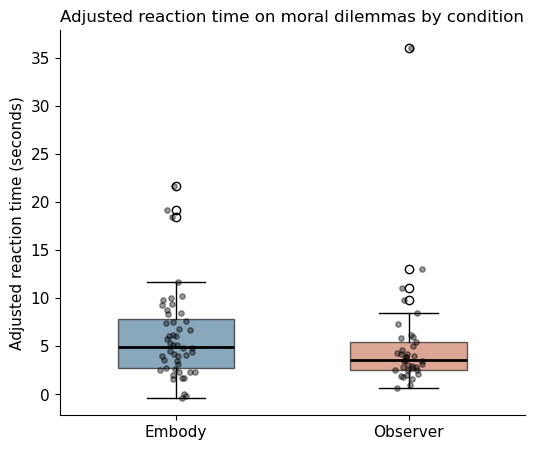

In [19]:
# Plot 1 - H1 - adjusted RT by condition
fig, ax = plt.subplots(figsize=(6, 5))

data = [
    merged[merged["condition"] == "Embody"]["adjusted_rt"],
    merged[merged["condition"] == "Observer"]["adjusted_rt"],
]

bp = ax.boxplot(data, labels=["Embody", "Observer"], widths=0.5, patch_artist=True,
                medianprops={"color": "black", "linewidth": 2})

for patch, colour in zip(bp["boxes"], [EMBODY_COLOUR, OBSERVER_COLOUR]):
    patch.set_facecolor(colour)
    patch.set_alpha(0.6)

# overlay individual points
for i, group in enumerate(data, start=1):
    x = np.random.normal(i, 0.04, size=len(group))
    ax.scatter(x, group, color="black", alpha=0.4, s=15, zorder=3)

ax.set_ylabel("Adjusted reaction time (seconds)")
ax.set_title("Adjusted reaction time on moral dilemmas by condition")
plt.tight_layout
plt.savefig("figure_1_rt_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

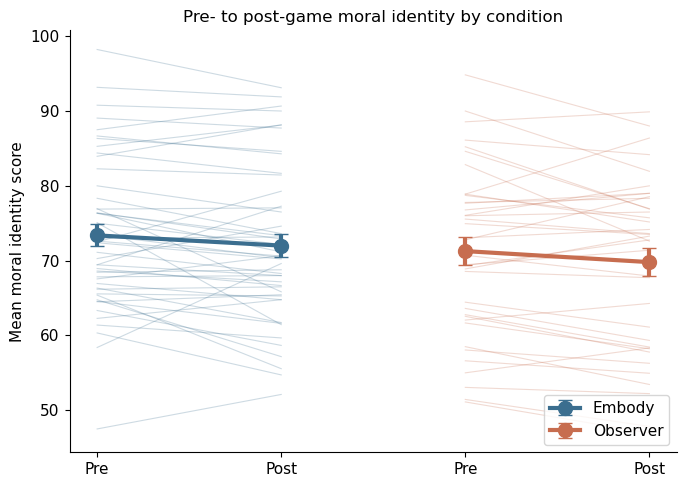

In [20]:
# Plot 2 - H2 - pre and post identity scores by condition
fig, ax = plt.subplots(figsize=(7, 5))

embody = merged[merged["condition"] == "Embody"]
observer = merged[merged["condition"] == "Observer"]

# plot individual lines for each participant
for _, row in embody.iterrows():
    ax.plot([0, 1], [row["mean_identity_pre"], row["mean_identity_post"]],
            color=EMBODY_COLOUR, alpha=0.25, linewidth=0.8)

for _, row in observer.iterrows():
    ax.plot([2, 3], [row["mean_identity_pre"], row["mean_identity_post"]],
            color=OBSERVER_COLOUR, alpha=0.25, linewidth=0.8)

# plot condition means with error bars
ax.errorbar([0, 1],
            [embody["mean_identity_pre"].mean(), embody["mean_identity_post"].mean()],
            yerr=[embody["mean_identity_pre"].sem(), embody["mean_identity_post"].sem()],
            color=EMBODY_COLOUR, linewidth=3, marker="o", markersize=10,
            capsize=5, label="Embody", zorder=5)

ax.errorbar([2, 3],
            [observer["mean_identity_pre"].mean(), observer["mean_identity_post"].mean()],
            yerr=[observer["mean_identity_pre"].sem(), observer["mean_identity_post"].sem()],
            color=OBSERVER_COLOUR, linewidth=3, marker="o", markersize=10,
            capsize=5, label="Observer", zorder=5)

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(["Pre", "Post", "Pre", "Post"])
ax.set_ylabel("Mean moral identity score")
ax.set_title("Pre- to post-game moral identity by condition")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

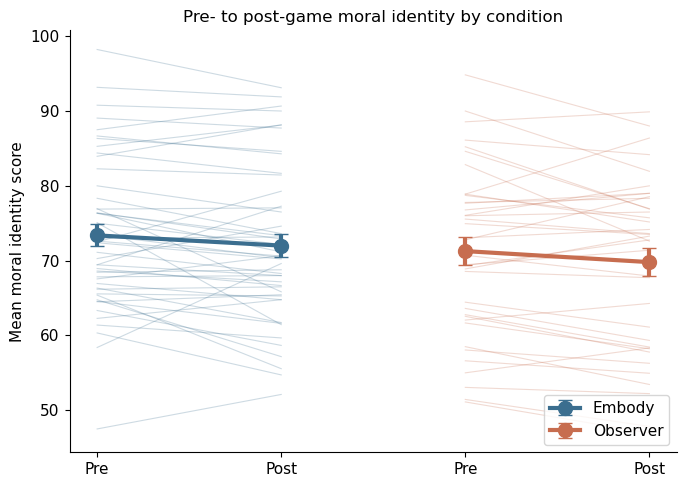

In [21]:
# Plot 2 - H2 - pre and post identity scores by condition
fig, ax = plt.subplots(figsize=(7, 5))

embody = merged[merged["condition"] == "Embody"]
observer = merged[merged["condition"] == "Observer"]

# plot individual lines for each participant
for _, row in embody.iterrows():
    ax.plot([0, 1], [row["mean_identity_pre"], row["mean_identity_post"]],
            color=EMBODY_COLOUR, alpha=0.25, linewidth=0.8)

for _, row in observer.iterrows():
    ax.plot([2, 3], [row["mean_identity_pre"], row["mean_identity_post"]],
            color=OBSERVER_COLOUR, alpha=0.25, linewidth=0.8)

# plot condition means with error bars
ax.errorbar([0, 1],
            [embody["mean_identity_pre"].mean(), embody["mean_identity_post"].mean()],
            yerr=[embody["mean_identity_pre"].sem(), embody["mean_identity_post"].sem()],
            color=EMBODY_COLOUR, linewidth=3, marker="o", markersize=10,
            capsize=5, label="Embody", zorder=5)

ax.errorbar([2, 3],
            [observer["mean_identity_pre"].mean(), observer["mean_identity_post"].mean()],
            yerr=[observer["mean_identity_pre"].sem(), observer["mean_identity_post"].sem()],
            color=OBSERVER_COLOUR, linewidth=3, marker="o", markersize=10,
            capsize=5, label="Observer", zorder=5)

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(["Pre", "Post", "Pre", "Post"])
ax.set_ylabel("Mean moral identity score")
ax.set_title("Pre- to post-game moral identity by condition")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figure_2_identity_lines.png", dpi=300, bbox_inches="tight")
plt.show()

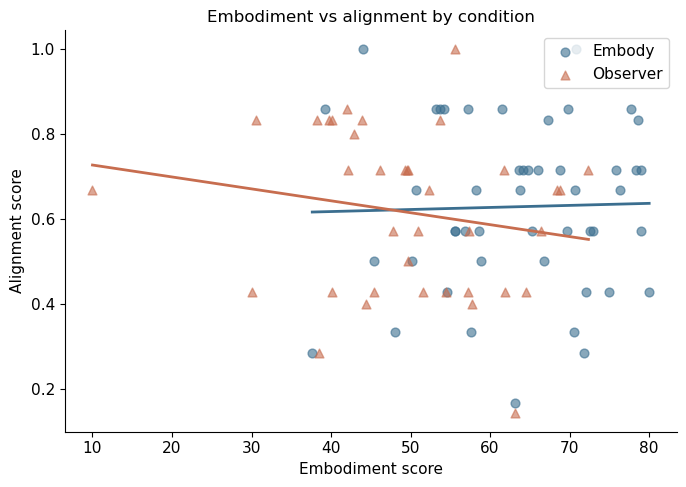

In [22]:
# Plot 3 - H3 - embodiment vs alignment by condition
fig, ax = plt.subplots(figsize=(7, 5))

embody = merged[merged["condition"] == "Embody"]
observer = merged[merged["condition"] == "Observer"]

# scatter points
ax.scatter(embody["embodiment_score"], embody["alignment_score"],
           color=EMBODY_COLOUR, alpha=0.6, s=40, label="Embody")
ax.scatter(observer["embodiment_score"], observer["alignment_score"],
           color=OBSERVER_COLOUR, alpha=0.6, s=40, label="Observer", marker="^")

# regression lines per condition
for group, colour in [(embody, EMBODY_COLOUR), (observer, OBSERVER_COLOUR)]:
    x = group["embodiment_score"].values
    y = group["alignment_score"].values
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color=colour, linewidth=2)

ax.set_xlabel("Embodiment score")
ax.set_ylabel("Alignment score")
ax.set_title("Embodiment vs alignment by condition")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("figure_3_embodiment_alignment.png", dpi=300, bbox_inches="tight")
plt.show()

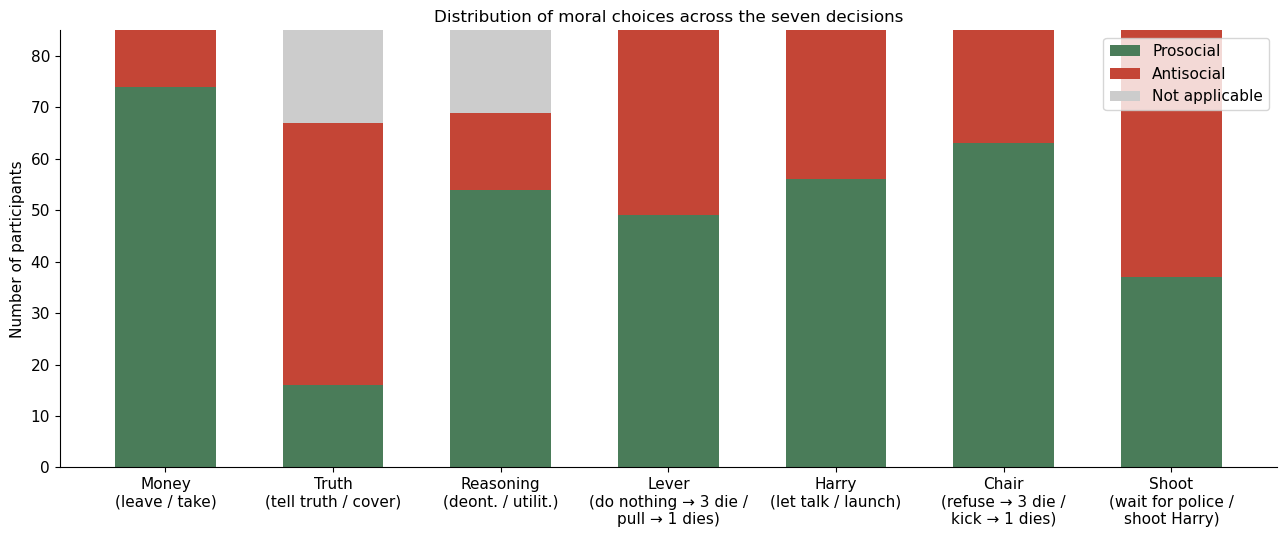

In [23]:
# Plot 4 - distribution of prosocial vs antisocial choices per moral decision
fig, ax = plt.subplots(figsize=(13, 5.5))

decisions = ["leave_money", "tell_truth", "reasoning", "lever", "harry_talk", "chair", "shoot"]
labels = [
    "Money\n(leave / take)",
    "Truth\n(tell truth / cover)",
    "Reasoning\n(deont. / utilit.)",
    "Lever\n(do nothing → 3 die /\npull → 1 dies)",
    "Harry\n(let talk / launch)",
    "Chair\n(refuse → 3 die /\nkick → 1 dies)",
    "Shoot\n(wait for police /\nshoot Harry)",
]

prosocial_counts = []
antisocial_counts = []
na_counts = []

for col in decisions:
    prosocial = (participant_choices[col] == 1).sum()
    antisocial = (participant_choices[col] == 0).sum()
    na = participant_choices[col].isna().sum()
    prosocial_counts.append(prosocial)
    antisocial_counts.append(antisocial)
    na_counts.append(na)

x = np.arange(len(decisions))
width = 0.6

ax.bar(x, prosocial_counts, width, label="Prosocial", color="#4a7c59")
ax.bar(x, antisocial_counts, width, bottom=prosocial_counts, label="Antisocial", color="#c44536")
ax.bar(x, na_counts, width,
       bottom=[p + a for p, a in zip(prosocial_counts, antisocial_counts)],
       label="Not applicable", color="#cccccc")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("Number of participants")
ax.set_title("Distribution of moral choices across the seven decisions")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("figure_4_choice_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
#money (leave it (prosocial) take it (antisocia), truth: tell colleague i won't lie for her (prosocial) or cover for her, she went home sick (antisocial)
#reasoning: do nothing (kill 1 is prosocial) or pull lever is antisocial
#harry talk: let him talk (prosocial) or launch at harry (antisocial)
#chair: refuse to kick (3 die, prosocial), or kick chair (kill 1 to save 3, antisocial)
# shoot harry (wait for police pro social), kill harry( anti social)

In [24]:
# exploratory - does embodiment correlate with any individual decision?
print("Embodiment vs each individual decision:")
print()

for col in choice_cols:
    # only use participants who have a valid choice (not NaN)
    sub = participant_choices[participant_choices[col].notna()].merge(
        merged[["participant_id", "embodiment_score", "condition"]],
        on="participant_id"
    )
    
    # full sample
    r, p = stats.spearmanr(sub["embodiment_score"], sub[col])
    
    # by condition
    sub_e = sub[sub["condition"] == "Embody"]
    sub_o = sub[sub["condition"] == "Observer"]
    r_e, p_e = stats.spearmanr(sub_e["embodiment_score"], sub_e[col])
    r_o, p_o = stats.spearmanr(sub_o["embodiment_score"], sub_o[col])
    
    print(f"{col}:")
    print(f"  Full sample: r = {r:.3f}, p = {p:.3f}  (n = {len(sub)})")
    print(f"  Embody:      r = {r_e:.3f}, p = {p_e:.3f}  (n = {len(sub_e)})")
    print(f"  Observer:    r = {r_o:.3f}, p = {p_o:.3f}  (n = {len(sub_o)})")
    print()

Embodiment vs each individual decision:

leave_money:
  Full sample: r = 0.174, p = 0.111  (n = 85)
  Embody:      r = -0.040, p = 0.785  (n = 48)
  Observer:    r = 0.197, p = 0.243  (n = 37)

tell_truth:
  Full sample: r = -0.078, p = 0.531  (n = 67)
  Embody:      r = -0.144, p = 0.369  (n = 41)
  Observer:    r = -0.037, p = 0.859  (n = 26)

reasoning:
  Full sample: r = 0.029, p = 0.812  (n = 69)
  Embody:      r = -0.093, p = 0.573  (n = 39)
  Observer:    r = 0.087, p = 0.649  (n = 30)

lever:
  Full sample: r = -0.046, p = 0.675  (n = 85)
  Embody:      r = -0.106, p = 0.473  (n = 48)
  Observer:    r = 0.041, p = 0.808  (n = 37)

harry_talk:
  Full sample: r = -0.028, p = 0.797  (n = 85)
  Embody:      r = 0.121, p = 0.412  (n = 48)
  Observer:    r = -0.214, p = 0.204  (n = 37)

chair:
  Full sample: r = -0.068, p = 0.537  (n = 85)
  Embody:      r = 0.105, p = 0.476  (n = 48)
  Observer:    r = -0.129, p = 0.446  (n = 37)

shoot:
  Full sample: r = -0.037, p = 0.735  (n = 85

In [25]:
# H1 sensitivity analysis - exclude RT outliers more than 2 SD BELOW the mean only
# rationale: very fast responders may not reflect genuine moral deliberation

# compute mean and SD on full sample
rt_mean = merged["adjusted_rt"].mean()
rt_sd = merged["adjusted_rt"].std()

# define lower bound only - very fast responders
lower_bound = rt_mean - 2 * rt_sd

# flag and count outliers
fast_outliers = merged[merged["adjusted_rt"] < lower_bound]
print(f"Outlier threshold: < {lower_bound:.2f} seconds")
print(f"Number of fast outliers excluded: {len(fast_outliers)}")
if len(fast_outliers) > 0:
    print(f"Outlier details:")
    print(fast_outliers[["participant_id", "condition", "adjusted_rt"]].to_string())

# create filtered sample
merged_no_fast = merged[merged["adjusted_rt"] >= lower_bound]

# rerun H1 on filtered sample
embody_rt_clean = merged_no_fast[merged_no_fast["condition"] == "Embody"]["adjusted_rt"]
observer_rt_clean = merged_no_fast[merged_no_fast["condition"] == "Observer"]["adjusted_rt"]

print(f"\nFiltered N: {len(merged_no_fast)} (Embody: {len(embody_rt_clean)}, Observer: {len(observer_rt_clean)})")

# normality check on filtered data
stat_e, p_e = stats.shapiro(embody_rt_clean)
stat_o, p_o = stats.shapiro(observer_rt_clean)
print(f"\nShapiro-Wilk filtered - Embody: p = {p_e:.3f}, Observer: p = {p_o:.3f}")

# choose test based on normality
if p_e > 0.05 and p_o > 0.05:
    stat_clean, p_clean = stats.ttest_ind(embody_rt_clean, observer_rt_clean)
    test_clean = "independent samples t-test"
else:
    stat_clean, p_clean = stats.mannwhitneyu(embody_rt_clean, observer_rt_clean, alternative="two-sided")
    test_clean = "Mann-Whitney U"

print(f"\nH1 with fast outliers excluded - {test_clean}")
print(f"statistic = {stat_clean:.3f}, p = {p_clean:.3f}")
print(f"Embody: M = {embody_rt_clean.mean():.3f}, SD = {embody_rt_clean.std():.3f}")
print(f"Observer: M = {observer_rt_clean.mean():.3f}, SD = {observer_rt_clean.std():.3f}")

Outlier threshold: < -4.77 seconds
Number of fast outliers excluded: 0

Filtered N: 85 (Embody: 48, Observer: 37)

Shapiro-Wilk filtered - Embody: p = 0.000, Observer: p = 0.000

H1 with fast outliers excluded - Mann-Whitney U
statistic = 1073.000, p = 0.102
Embody: M = 6.008, SD = 4.640
Observer: M = 5.161, SD = 5.892


In [26]:
import pandas as pd
import numpy as np
import scipy
import matplotlib
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

pandas: 2.3.3
numpy: 2.3.5
scipy: 1.16.3
matplotlib: 3.10.6


In [27]:
from scipy.stats import linregress

#Exploratory analysis for H3
# residualise alignment on pre-game identity
# this isolates the variance in alignment NOT explained by pre-game identity
slope, intercept, r_val, p_val, _ = linregress(merged["mean_identity_pre"], merged["alignment_score"])
predicted_alignment = slope * merged["mean_identity_pre"] + intercept
alignment_residuals = merged["alignment_score"] - predicted_alignment

# correlate residuals with embodiment
r_resid, p_resid = stats.spearmanr(merged["embodiment_score"], alignment_residuals)
print(f"Embodiment vs alignment residuals (controlling for pre-game identity):")
print(f"  ρ = {r_resid:.3f}, p = {p_resid:.3f}")
print(f"\nCompared to original H3 (no control): ρ = -0.047, p = .672")

# by condition
embody = merged[merged["condition"] == "Embody"]
observer = merged[merged["condition"] == "Observer"]

slope_e, intercept_e, _, _, _ = linregress(embody["mean_identity_pre"], embody["alignment_score"])
predicted_e = slope_e * embody["mean_identity_pre"] + intercept_e
resid_e = embody["alignment_score"] - predicted_e
r_emb, p_emb = stats.spearmanr(embody["embodiment_score"], resid_e)

slope_o, intercept_o, _, _, _ = linregress(observer["mean_identity_pre"], observer["alignment_score"])
predicted_o = slope_o * observer["mean_identity_pre"] + intercept_o
resid_o = observer["alignment_score"] - predicted_o
r_obs, p_obs = stats.spearmanr(observer["embodiment_score"], resid_o)

print(f"\nBy condition:")
print(f"  Embody: ρ = {r_emb:.3f}, p = {p_emb:.3f}")
print(f"  Observer: ρ = {r_obs:.3f}, p = {p_obs:.3f}")

# moderation check - split on median pre-game identity
median_id = merged["mean_identity_pre"].median()
high_id = merged[merged["mean_identity_pre"] >= median_id]
low_id = merged[merged["mean_identity_pre"] < median_id]

r_high, p_high = stats.spearmanr(high_id["embodiment_score"], high_id["alignment_score"])
r_low, p_low = stats.spearmanr(low_id["embodiment_score"], low_id["alignment_score"])

print(f"\nModeration by pre-game identity:")
print(f"  High pre-game identity (n={len(high_id)}): ρ = {r_high:.3f}, p = {p_high:.3f}")
print(f"  Low pre-game identity (n={len(low_id)}): ρ = {r_low:.3f}, p = {p_low:.3f}")

Embodiment vs alignment residuals (controlling for pre-game identity):
  ρ = -0.066, p = 0.550

Compared to original H3 (no control): ρ = -0.047, p = .672

By condition:
  Embody: ρ = 0.016, p = 0.912
  Observer: ρ = -0.286, p = 0.087

Moderation by pre-game identity:
  High pre-game identity (n=43): ρ = -0.205, p = 0.188
  Low pre-game identity (n=42): ρ = 0.065, p = 0.681
